In [325]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

%matplotlib inline

In [326]:
# --- Loading the train dataset
train_dataset = pd.read_csv('data/train_dataset.csv')

# --- Loading the dataset
test_dataset = pd.read_csv('data/test_dataset.csv')
    

In [327]:
# --- Defining the function that will use the model to complete the test dataset

def complete_dataset(model_name, model):

    # Loading the test dataset
    test_dataset = pd.read_csv('data/test_dataset.csv')

    # Making the predictions
    test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred

    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)

    # Creating a RowId column
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)

    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]

    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {0: 'CN-CN', 1: 'AD-AD', 2: 'CN-MCI', 3: 'MCI-AD', 4: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()

    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)

In [328]:
# --- Defining features and target
X = train_dataset.drop('Transition', axis=1)
y = train_dataset['Transition']

In [329]:
# Dropping the oversampled column if it exists in features
if 'oversampled' in X.columns:
    X = X.drop(columns=['oversampled'])


## Random Forest

In [330]:
# --- Implementing a Random Forest model

# Defining the hyperparameter distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 6, 12, 20, None]
}

# Initializing base model
base_rf = RandomForestClassifier(random_state=123)

oversampling_indicator = train_dataset['oversampled'] # will be used to guarantee that oversampled data is only used in training

# Getting indices for non-oversampled and oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold for non-oversampled data
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Creating custom split indices that include oversampled data in training byt not in validation
custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices], 
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices from non_oversampled_indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))

# Initializing RandomizedSearchCV with custom splits. This will search for the best hyperparameters
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=custom_splits,
    scoring='f1_macro',
    random_state=123,
    n_jobs=-1,
    verbose=1
)

# Fitting the random search
random_search.fit(X, y)

# Getting the best model
best_rf = random_search.best_estimator_

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing final cross-validation with best model
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    # Training best model on combined data (original + oversampled)
    best_rf.fit(X.loc[train_idx], y.loc[train_idx])
    
    # Predicting on validation set (non-oversampled only)
    val_pred = best_rf.predict(X.loc[val_idx])
    val_prob = best_rf.predict_proba(X.loc[val_idx])
    
    # Storing predictions
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('Random Forest Classifier Results:')
print('Best Parameters:', random_search.best_params_)
print('Best Cross-Validation Score:', random_search.best_score_)
print('Final Macro F1 Score:', f1_macro)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Random Forest Classifier Results:
Best Parameters: {'n_estimators': 100, 'max_depth': 6}
Best Cross-Validation Score: 0.3300397269965045
Final Macro F1 Score: 0.34008119876718085


In [331]:
# --- Analyzing the confusion matrix

y_non_oversampled = y.loc[non_oversampled_indices]
rfc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, rfc_pred))

Confusion matrix
[[76  4  0  8  8]
 [ 7 28  0 17  8]
 [ 8  1  0  1  0]
 [19 17  0 21 11]
 [35  7  0 14 15]]


Text(0.5, -0.1, 'Confusion matrix for Random Forest Classifier')

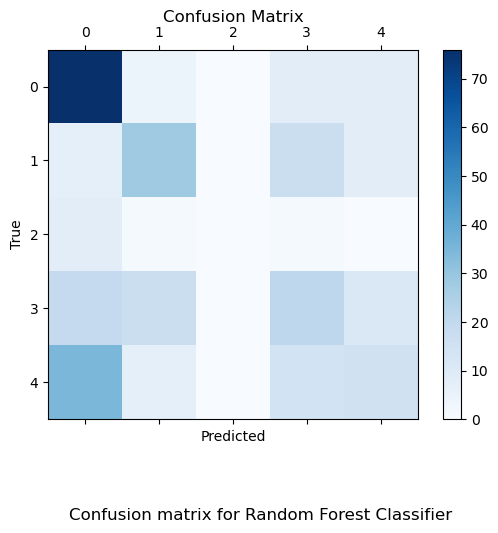

In [332]:

# --- Plotting the confusion matrix
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, rfc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for Random Forest Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

In [333]:
# --- Completing the test dataset
complete_dataset('RandomForestClassifier', best_rf)

## XGBoost

In [334]:
# --- Implementing an XGBoost model

oversampling_indicator = train_dataset['oversampled']

# Initializing XGBoost with best parameters
xgbc = xgb.XGBClassifier(
    objective='multi:softprob',
    random_state=123,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    xgbc.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
        # Optional: add sample weights if needed
        # sample_weight=compute_sample_weights(y.loc[final_train_idx])
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = xgbc.predict(X.loc[actual_val_idx])
    val_prob = xgbc.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('\nFinal XGBoost Classifier')
print(f'Overall Macro F1 Score: {f1_macro:.3f}')


Final XGBoost Classifier
Overall Macro F1 Score: 0.327


In [335]:
# --- Analyzing the confusion matrix

xgbc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, xgbc_pred))

Confusion matrix
[[68  4  0  9 15]
 [ 6 28  0 16 10]
 [ 7  1  0  2  0]
 [11 21  0 21 15]
 [27  9  0 20 15]]


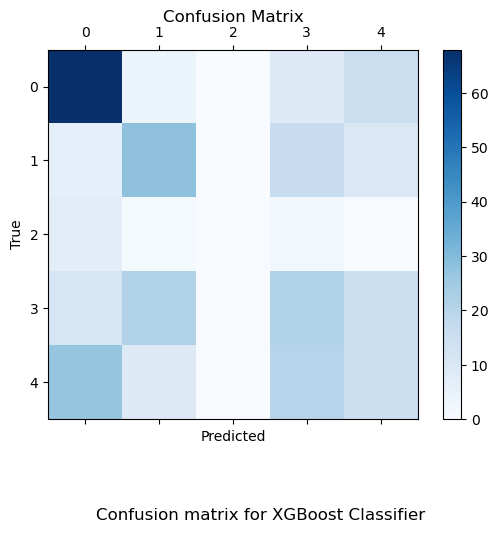

In [336]:
# --- Plotting the confusion matrix with a caption
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, xgbc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for XGBoost Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [337]:
# Completing the test dataset
complete_dataset('xgboost', xgbc)

## SVM

In [338]:
# --- SVM MODEL ---
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Defining the hyperparameter distributions
param_distributions = {
    'svc__C': np.logspace(-3, 3, 7),
    'svc__gamma': ['scale', 'auto'] + list(np.logspace(-3, 3, 7))
}

# Initializing the SVM model with pipeline
svm = make_pipeline(
    StandardScaler(),
    SVC(
        random_state=123,
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        cache_size=1000
    )
)

oversampling_indicator = train_dataset['oversampled']

# Getting indices of non-oversampled and oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))

svm = RandomizedSearchCV(
    svm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

svm.fit(X, y)

best_svm = svm.best_estimator_

# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), len(np.unique(y))))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    best_svm.fit(X.iloc[train_idx], y.loc[train_idx])
    
    # Predicting on validation set
    val_pred = best_svm.predict(X.loc[val_idx])
    val_prob = best_svm.predict_proba(X.loc[val_idx])
    
    # Storing predictions and probabilities
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('\nFinal SVM Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final SVM Results
Overall Macro F1 Score: 0.327


In [339]:
# Complete the dataset
complete_dataset('svm', svm)

## Logistic Regression

In [340]:
# --- LOGISTIC REGRESSION ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Optional: Add hyperparameter tuning
param_distributions = {
    'logisticregression__C': np.logspace(-4, 4, 9),
    'logisticregression__penalty': ['l1', 'l2', 'elasticnet'],
    'logisticregression__l1_ratio': [0.2, 0.5, 0.9]
}

# Initializing the logistic regression model with pipeline
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=123,
        max_iter=2000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    )
)

oversampling_indicator = train_dataset['oversampled']

non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))


log_reg = RandomizedSearchCV(
    log_reg,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

log_reg.fit(X, y)
best_log_reg = log_reg.best_estimator_


# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), len(np.unique(y))))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(custom_splits):

    # Training model
    best_log_reg.fit(X.iloc[train_idx], y.iloc[train_idx])

    # Predicting on validation set
    val_pred = best_log_reg.predict(X.loc[val_idx])
    val_prob = best_log_reg.predict_proba(X.loc[val_idx])
    
    # Storing predictions and probabilities
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('\nFinal Logistic Regression Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')

c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users


Final Logistic Regression Results
Overall Macro F1 Score: 0.297


c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [341]:
# Complete the dataset
complete_dataset('logreg', log_reg)

In [342]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Optional: Add hyperparameter tuning
param_distributions = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'feature_fraction': [0.6, 0.7, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
    'min_child_samples': [10, 20, 30, 50]
}

# Initializing LightGBM with better parameters for your case
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    random_state=123,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    class_weight='balanced',  # Handle class imbalance
    boosting_type='goss',    # Gradient-based One-Side Sampling, good for imbalanced data
    verbose=-1,              
    n_jobs=-1,              
    feature_fraction=0.8,    
    reg_alpha=0.1,          
    reg_lambda=0.1,         
    min_child_samples=20    
)


oversampling_indicator = train_dataset['oversampled']

non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))


lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

lgbm.fit(X, y)
best_lgbm = lgbm.best_estimator_


# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))  # 5 classes

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    
    best_lgbm.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # Predicting on validation set
    val_pred = best_lgbm.predict(X.loc[val_idx])
    val_prob = best_lgbm.predict_proba(X.loc[val_idx])

    # Storing predictions and probabilities
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob
    
# Calculating final scores
final_f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('\nFinal LightGBM Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')


Final LightGBM Results
Overall Macro F1 Score: 0.331


In [343]:
# Complete the dataset
complete_dataset('lightgbm', lgbm)